In [16]:
import numpy as np

np.random.seed(42)

# Product catalog — 3 semantic clusters: electronics, clothing, furniture
products = [
    "Wireless noise-cancelling headphones with 30-hour battery",
    "Bluetooth speaker with waterproof design",
    "USB-C hub with 7 ports and power delivery",
    "4K HDMI cable 6ft braided",
    "Mechanical keyboard with RGB backlight",
    "Men's slim-fit chino pants navy blue",
    "Women's merino wool turtleneck sweater",
    "Unisex running jacket lightweight windbreaker",
    "Leather chelsea boots for men",
    "Organic cotton crew neck t-shirt",
    "Solid oak dining table seats 6",
    "Ergonomic mesh office chair lumbar support",
    "Linen sofa 3-seater natural beige",
    "Bamboo bookshelf 5-tier adjustable",
    "Memory foam mattress queen size medium firm",
]

# Simulate embeddings with cluster structure
# Cluster centers in 8D space
electronics_center = np.array([0.9, 0.1, 0.2, 0.8, 0.1, 0.3, 0.7, 0.2])
clothing_center    = np.array([0.1, 0.8, 0.7, 0.1, 0.9, 0.2, 0.1, 0.8])
furniture_center   = np.array([0.2, 0.3, 0.9, 0.2, 0.1, 0.9, 0.3, 0.1])

n_per_cluster = 5
noise = 0.08

embeddings = np.vstack([
    electronics_center + np.random.randn(n_per_cluster, 8) * noise,
    clothing_center    + np.random.randn(n_per_cluster, 8) * noise,
    furniture_center   + np.random.randn(n_per_cluster, 8) * noise,
])

print(f"Embeddings shape: {embeddings.shape}")
# Output: Embeddings shape: (15, 8)

Embeddings shape: (15, 8)


In [17]:
def normalize(vectors: np.ndarray) -> np.ndarray:
    """L2-normalize each row vector."""
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    # Avoid division by zero
    norms = np.where(norms == 0, 1e-10, norms)
    return vectors / norms


class VectorIndex:
    def __init__(self):
        self.vectors = None
        self.labels = None

    def add(self, vectors: np.ndarray, labels: list):
        self.vectors = normalize(vectors)
        self.labels = labels
        print(f"Indexed {len(labels)} items with {vectors.shape[1]}-dimensional embeddings.")

    def search(self, query_vector: np.ndarray, top_k: int = 3):
        query_norm = normalize(query_vector.reshape(1, -1))
        # Cosine similarity = dot product of normalized vectors
        scores = self.vectors @ query_norm.T  # shape: (n_items, 1)
        scores = scores.flatten()
        # Get top-k indices sorted by descending score
        top_indices = np.argsort(scores)[::-1][:top_k]
        return [(self.labels[i], float(scores[i])) for i in top_indices]


index = VectorIndex()
index.add(embeddings, products)

Indexed 15 items with 8-dimensional embeddings.


In [18]:
def make_query(center: np.ndarray, noise_scale: float = 0.05) -> np.ndarray:
    return center + np.random.randn(8) * noise_scale


queries = {
    "audio equipment": make_query(electronics_center),
    "casual wear":     make_query(clothing_center),
    "home furniture":  make_query(furniture_center),
}

for query_name, q_vec in queries.items():
    print(f"\nQuery: '{query_name}'")
    results = index.search(q_vec, top_k=3)
    for rank, (label, score) in enumerate(results, 1):
        print(f"  {rank}. [{score:.4f}] {label}")


Query: 'audio equipment'
  1. [0.9856] Wireless noise-cancelling headphones with 30-hour battery
  2. [0.9840] USB-C hub with 7 ports and power delivery
  3. [0.9829] Mechanical keyboard with RGB backlight

Query: 'casual wear'
  1. [0.9960] Men's slim-fit chino pants navy blue
  2. [0.9958] Leather chelsea boots for men
  3. [0.9916] Women's merino wool turtleneck sweater

Query: 'home furniture'
  1. [0.9929] Bamboo bookshelf 5-tier adjustable
  2. [0.9902] Linen sofa 3-seater natural beige
  3. [0.9881] Solid oak dining table seats 6


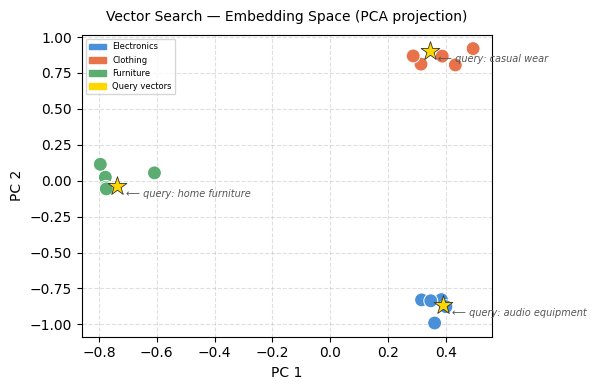

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

projected = pca_2d(embeddings)

cluster_colors = (
    ["#4A90D9"] * 5 +   # electronics — blue
    ["#E8734A"] * 5 +   # clothing — orange
    ["#5BAD72"] * 5     # furniture — green
)
cluster_labels = ["Electronics"] * 5 + ["Clothing"] * 5 + ["Furniture"] * 5

fig, ax = plt.subplots(figsize=(6, 4)) # Further reduced figure size
ax.scatter(projected[:, 0], projected[:, 1],
           c=cluster_colors, s=100, edgecolors="white", linewidths=0.7, zorder=3)

# Removed: Annotation loop for individual product labels

# Plot query projections
q_projected = pca_2d(
    np.vstack(list(queries.values())) - embeddings.mean(axis=0)
)
for (qname, _), (qx, qy) in zip(queries.items(), q_projected):
    ax.scatter(qx, qy, marker="*", s=200, color="gold",
               edgecolors="#333", linewidths=0.6, zorder=4)
    ax.annotate(f"⟵ query: {qname}", (qx, qy),
                textcoords="offset points", xytext=(6, -8),
                fontsize=7, color="#555555", style="italic")

legend_patches = [
    mpatches.Patch(color="#4A90D9", label="Electronics"),
    mpatches.Patch(color="#E8734A", label="Clothing"),
    mpatches.Patch(color="#5BAD72", label="Furniture"),
    mpatches.Patch(color="gold",    label="Query vectors"),
]
ax.legend(handles=legend_patches, loc="upper left", fontsize=6) # Further reduced legend font size
ax.set_title("Vector Search — Embedding Space (PCA projection)", fontsize=10, pad=10) # Further reduced title font size
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("embedding_space_queries_only.png", dpi=150)
plt.show()

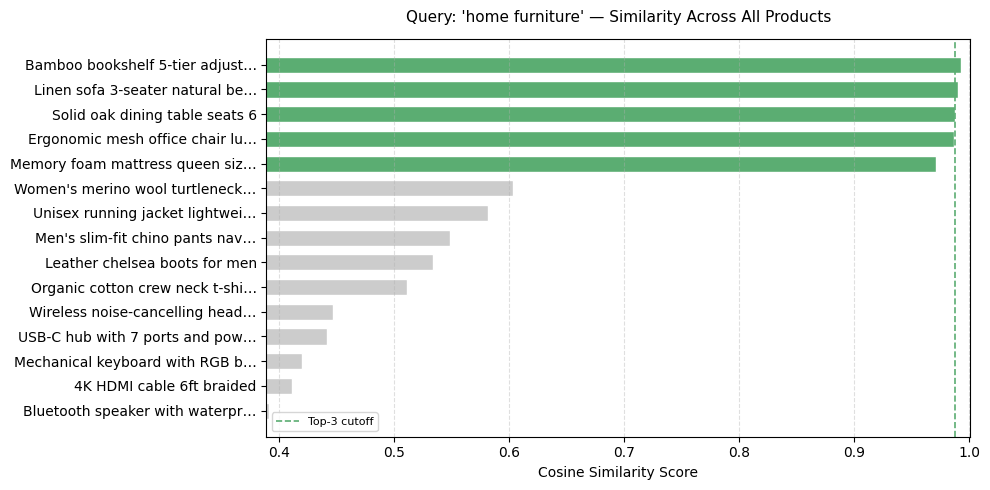

In [20]:
q_vec_furniture = queries["home furniture"]
q_norm_furniture = normalize(q_vec_furniture.reshape(1, -1))
all_scores_furniture = (index.vectors @ q_norm_furniture.T).flatten()

sorted_idx_furniture = np.argsort(all_scores_furniture)[::-1]
sorted_scores_furniture = all_scores_furniture[sorted_idx_furniture]
sorted_labels_furniture = [products[i][:30] + "…" if len(products[i]) > 30
                           else products[i] for i in sorted_idx_furniture]

# Define bar colors: green for furniture items, gray for others
bar_colors_furniture = []
for i in sorted_idx_furniture:
    if i >= 10 and i <= 14:  # Furniture items are originally at indices 10-14
        bar_colors_furniture.append("#5BAD72") # Green for furniture
    else:
        bar_colors_furniture.append("#cccccc") # Gray for others

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_labels_furniture[::-1], sorted_scores_furniture[::-1],
               color=bar_colors_furniture[::-1], edgecolor="white", height=0.65)

ax.axvline(sorted_scores_furniture[2], color="#5BAD72", linestyle="--", # Green line for furniture cutoff
           linewidth=1.2, label="Top-3 cutoff")
ax.set_xlim(sorted_scores_furniture.min() - 0.002, 1.001)
ax.set_xlabel("Cosine Similarity Score")
ax.set_title("Query: 'home furniture' — Similarity Across All Products", fontsize=11, pad=12)
ax.legend(fontsize=8)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("score_distribution_furniture.png", dpi=150)
plt.show()